# L12d: LSTM Networks for Fed-Batch CHO Bioreactor Prediction
In this lab, we apply a Long Short-Term Memory (LSTM) network to predict the full state trajectory of a fed-batch Chinese Hamster Ovary (CHO) cell bioreactor producing a monoclonal antibody. We generate training data by simulating a kinetic CHO model at different glucose-triggered feed policies, train an LSTM to predict all seven bioreactor states, and evaluate predictions on unseen feed conditions.

> __Learning Objectives:__
>
> By the end of this lab, you should be able to:
>
> * __Generate fed-batch CHO bioreactor data from ODE simulations:__ Simulate a kinetic model of CHO cell growth and antibody production at different glucose-triggered feed policies and organize the multi-state data for LSTM training.
> * __Implement and train an LSTM for multi-state autoregressive prediction:__ Build an LSTM from scratch, train it using teacher forcing with gradient-based optimization, and connect the gating architecture to the equations from the lecture.
> * __Evaluate LSTM predictions on unseen feed conditions:__ Use autoregressive rollout to generate full predicted state trajectories on held-out feed policies and compare predictions to ground truth.

Let's get started!
___

## Setup, Data, and Prerequisites
We set up the computational environment by including the `Include.jl` file, loading any needed resources, such as sample datasets, and setting up any required constants.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, and includes local source files in `src/`. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-12/L12d`


In addition to standard Julia libraries, this example uses [the `OrdinaryDiffEq.jl` package](https://github.com/SciML/OrdinaryDiffEq.jl) for solving the CHO bioreactor ODE system and [the `Flux.jl` package](https://fluxml.ai/Flux.jl/stable/) for gradient computation and optimization. The CHO kinetic model is implemented from scratch in the `src/` directory following fed-batch bioreactor modeling conventions.

### Implementations
We use helper functions defined in the `src/` directory:

| Function | Source | Description |
| --- | --- | --- |
| [`build_default_parameters(...)`](src/Parameters.jl) | `src/Parameters.jl` | Construct CHO model parameters for a given feed policy |
| [`growth_rate(...)`](src/Kinetics.jl) | `src/Kinetics.jl` | Monod growth rate with by-product inhibition |
| [`product_formation_rate(...)`](src/Kinetics.jl) | `src/Kinetics.jl` | Specific antibody productivity |
| [`substrate_uptake_glucose(...)`](src/Kinetics.jl) | `src/Kinetics.jl` | Specific glucose uptake rate |
| [`substrate_uptake_glutamine(...)`](src/Kinetics.jl) | `src/Kinetics.jl` | Specific glutamine uptake rate |
| [`byproduct_formation_lactate(...)`](src/Kinetics.jl) | `src/Kinetics.jl` | Specific lactate formation rate |
| [`byproduct_formation_ammonia(...)`](src/Kinetics.jl) | `src/Kinetics.jl` | Specific ammonia formation rate |
| [`simulate_fedbatch(...)`](src/Simulation.jl) | `src/Simulation.jl` | Solve the fed-batch CHO ODE system with feed callbacks |
| [`generate_cho_dataset(...)`](src/Simulation.jl) | `src/Simulation.jl` | Generate multi-condition CHO datasets |
| [`normalize_minmax_perstate(...)`](src/Simulation.jl) | `src/Simulation.jl` | Per-state normalization using training bounds |
| [`denormalize_minmax(...)`](src/Simulation.jl) | `src/Simulation.jl` | Reverse per-state normalization |
| [`build_lstm(...)`](src/LSTM.jl) | `src/LSTM.jl` | Initialize an LSTM with Xavier-scaled weights |
| [`forward_step(...)`](src/LSTM.jl) | `src/LSTM.jl` | Compute one LSTM time step |
| [`forward_sequence(...)`](src/LSTM.jl) | `src/LSTM.jl` | Run the LSTM over a full sequence with teacher forcing |
| [`predict_sequence(...)`](src/LSTM.jl) | `src/LSTM.jl` | Generate a predicted sequence via autoregressive rollout |
| [`count_parameters(...)`](src/LSTM.jl) | `src/LSTM.jl` | Count total trainable parameters |

### Constants
We define simulation and training constants used throughout the example. The simulation constants control the feed policy ranges and time resolution, while the LSTM constants specify the network architecture and training hyperparameters.

In [2]:
# simulation constants -
number_of_conditions = 50;       # total number of feed policy conditions to simulate
tspan = (0.0, 336.0);           # simulation time span: 0 to 336 hours (14 days)
saveat = 1.0;                    # save ODE solution every 1 hour (337 time points)


# initial conditions: matches L12c-Advanced-CHO-Simulation baseline -
u0_baseline = [10.0, 0.3, 25.0, 8.0, 0.0, 0.0, 0.0]; # [V (L), X (gDW/L), Glc (mM), Gln (mM), P (mg/L), Lac (mM), Amm (mM)]

# feed policy ranges for conditioning -
F_max_range = (0.01, 0.50);     # maximum feed rate range (L/h)
Glc_min_range = (1.0, 5.0);      # glucose lower threshold range (mM)
Glc_max_range = (10.0, 30.0);    # glucose upper threshold range (mM)

# state labels for plotting -
state_labels = ["V (L)", "X (gDW/L)", "Glc (mM)", "Gln (mM)", "mAb (mg/L)", "Lac (mM)", "Amm (mM)"];

# LSTM architecture constants -
d_in = 10;                       # input dimension: 7 states + 3 conditioning (F_max, Glc_min, Glc_max)
h_dim = 128;                     # hidden state dimension
d_out = 7;                       # output dimension: predict all 7 states

# training constants -
num_epochs = 500;                # number of training epochs
learning_rate = 1e-3;            # Adam optimizer learning rate
train_fraction = 0.8;            # fraction of conditions used for training (80% train, 20% test)
grad_clip = 1.0;                 # gradient clipping threshold (max gradient norm)

___

## Task 1: Generate Fed-Batch CHO Bioreactor Data
We simulate a kinetic model of CHO cell growth and antibody production under different glucose-triggered feed policies. The feed operates as a square wave with hysteresis: it turns ON when glucose drops below `Glc_min` and turns OFF when glucose rises above `Glc_max`.

> __Glucose-triggered fed-batch operation__
>
> In fed-batch CHO cell culture, a concentrated nutrient feed is added to the bioreactor to sustain cell growth and antibody production (a fed-batch process has inputs, but no outputs until harvest). The feed policy determines how and when nutrients are delivered. 
> * __Feed policy__: Instead of a fixed feed schedule (which is typical), we use a glucose-triggered strategy: the feed turns on when glucose is depleted below a lower threshold and turns off when glucose has been replenished above an upper threshold. This creates cycling patterns in glucose, which propagate through the entire bioreactor state (biomass, product, by-products). 
> 
> Different feed policies (F_max, Glc_min, Glc_max) produce different growth and production dynamics. We simulate 50 conditions with randomly sampled feed policies using [the `generate_cho_dataset(...)` function](src/Simulation.jl).

The feed policy parameters are sampled uniformly within the specified ranges using [the `rand(...)` function](https://docs.julialang.org/en/v1/stdlib/Random/#Base.rand). The simulation results are stored in the `time_vector::Vector{Float64}` variable (time points in hours), the `state_arrays::Vector{Matrix{Float64}}` variable (each element is a T x 7 matrix of states), and the `conditions` variable (feed policy tuples).

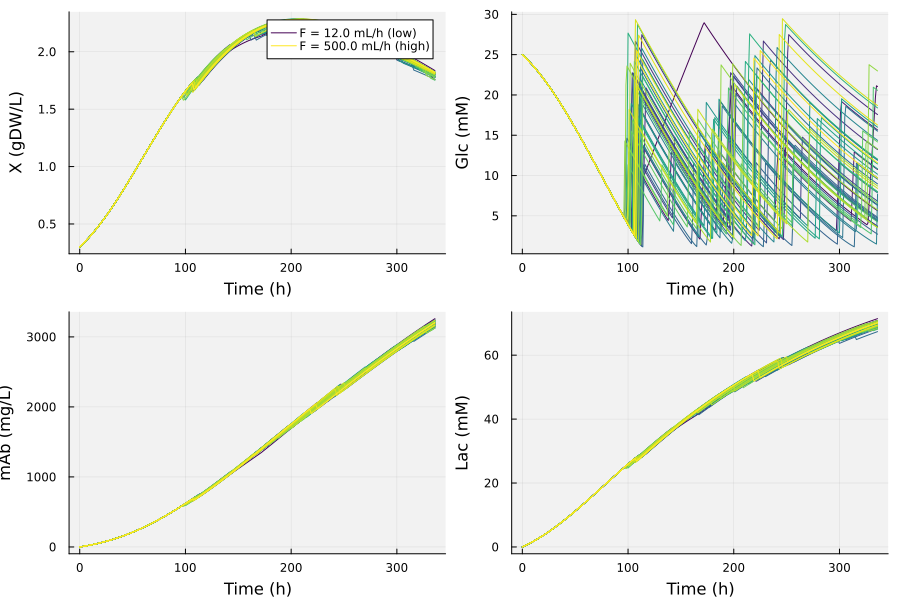

In [3]:
time_vector, state_arrays, conditions = let

    # generate random feed policy conditions -
    Random.seed!(42);
    conditions = Vector{Tuple{Float64,Float64,Float64}}(undef, number_of_conditions);
    for i in 1:number_of_conditions
        F_max = F_max_range[1] + rand() * (F_max_range[2] - F_max_range[1]);
        Glc_min = Glc_min_range[1] + rand() * (Glc_min_range[2] - Glc_min_range[1]);
        Glc_max = Glc_max_range[1] + rand() * (Glc_max_range[2] - Glc_max_range[1]);
        conditions[i] = (F_max, Glc_min, Glc_max);
    end

    # simulate the CHO model at each feed policy condition -
    time_vector, state_arrays, conditions = generate_cho_dataset(conditions;
        u0 = u0_baseline, tspan = tspan, saveat = saveat);

    # visualize 4 key states colored by F_max -
    colors = palette(:viridis, number_of_conditions);
    sort_order = sortperm([c[1] for c in conditions]);
    plot_states = [(2, "X (gDW/L)"), (3, "Glc (mM)"), (5, "mAb (mg/L)"), (6, "Lac (mM)")];
    panels = [];
    for (si, (s_idx, s_label)) in enumerate(plot_states)
        show_legend = (si == 1); # legend only on first panel
        p = plot(xlabel="Time (h)", ylabel=s_label,
            background_color_inside=:gray95, legend=(show_legend ? :topright : false));
        for (rank, j) in enumerate(sort_order)
            label_str = if show_legend && rank == 1
                "F = $(round(conditions[j][1]*1000, digits=0)) mL/h (low)"
            elseif show_legend && rank == number_of_conditions
                "F = $(round(conditions[j][1]*1000, digits=0)) mL/h (high)"
            else
                ""
            end;
            plot!(p, time_vector, state_arrays[j][:, s_idx], color=colors[rank], lw=1.0, label=label_str);
        end
        push!(panels, p);
    end
    display(plot(panels..., layout=(2, 2), size=(900, 600)))

    # return simulation data -
    (time_vector, state_arrays, conditions)
end;


The curves show that different feed policies produce different antibody production trajectories. Higher feed rates generally support more biomass and higher titers, but also produce more by-products.

Next, we normalize the data per-state using bounds computed from the training set only, using [the `normalize_minmax_perstate(...)` function](src/Simulation.jl), and split into training and test sets using [the `randperm(...)` function](https://docs.julialang.org/en/v1/stdlib/Random/#Random.randperm). 
* __Why per-state normalization?__ Per-state normalization handles the different scales of the 7 states (volume in L, biomass in gDW/L, glucose in mM, antibody in mg/L, etc.). Using training-only bounds prevents data leakage. 

The normalized state arrays are stored in `X_norm_arrays`, the per-state bounds in `state_mins` and `state_maxs`, the normalized conditioning vectors in `cond_norm`, and the training and test indices in `train_idx` and `test_idx`.

In [4]:
X_norm_arrays, state_mins, state_maxs, cond_norm, cond_mins, cond_maxs, train_idx, test_idx = let

    # shuffle and split into train/test sets -
    Random.seed!(42);
    perm = randperm(number_of_conditions);
    n_train = Int(round(train_fraction * number_of_conditions));
    train_idx = perm[1:n_train];
    test_idx = perm[(n_train+1):end];

    # normalize states per-state using training bounds only -
    X_norm_arrays, state_mins, state_maxs = normalize_minmax_perstate(state_arrays, train_idx);

    # normalize conditioning vectors to [0, 1] using training bounds -
    cond_matrix = hcat([[c...] for c in conditions]...)'; # (n_conditions x 3)
    cond_mins = vec(minimum(cond_matrix[train_idx, :], dims=1));
    cond_maxs = vec(maximum(cond_matrix[train_idx, :], dims=1));
    cond_norm = Vector{Vector{Float64}}(undef, number_of_conditions);
    for i in 1:number_of_conditions
        cond_norm[i] = (collect(conditions[i]) .- cond_mins) ./ (cond_maxs .- cond_mins);
    end

    # print dataset summary -
    println("Dataset: $(number_of_conditions) conditions, $(size(state_arrays[1], 1)) time points each");
    println("Training: $(length(train_idx)) conditions, Test: $(length(test_idx)) conditions");
    println("States: $(join(state_labels, ", "))");

    # return all outputs -
    (X_norm_arrays, state_mins, state_maxs, cond_norm, cond_mins, cond_maxs, train_idx, test_idx)
end;

Dataset: 50 conditions, 337 time points each
Training: 40 conditions, Test: 10 conditions
States: V (L), X (gDW/L), Glc (mM), Gln (mM), mAb (mg/L), Lac (mM), Amm (mM)


___

## Task 2: Build the LSTM
We construct an LSTM following the architecture from the [L12c lecture on LSTM Networks](CHEME-5820-L12c-Lecture-LSTM-Spring-2026.ipynb). The LSTM operates in an autoregressive mode: at each time step $t$, it receives the current state vector $\mathbf{s}_t \in \mathbb{R}^{7}$ concatenated with the conditioning parameters $\mathbf{c} \in \mathbb{R}^{3}$ and predicts the next state $\hat{\mathbf{s}}_{t+1}$.

> __LSTM Architecture__
>
> LSTMs use gates to address the vanishing gradient problem. Each gate serves a specific role. The __forget gate__ $\mathbf{f}_t$ controls what information to discard from the previous cell state. The __input gate__ $\mathbf{i}_t$ controls what new information to write to the cell state. The __output gate__ $\mathbf{o}_t$ controls what information from the cell state to expose as the hidden state.The following equations describe the LSTM cell:
> $$
\boxed{
\begin{align*}
\mathbf{f}_t &= \sigma(\mathbf{W}_f \mathbf{x}_t + \mathbf{U}_f \mathbf{h}_{t-1} + \mathbf{b}_f) & \text{(forget gate)} \\
\mathbf{i}_t &= \sigma(\mathbf{W}_i \mathbf{x}_t + \mathbf{U}_i \mathbf{h}_{t-1} + \mathbf{b}_i) & \text{(input gate)} \\
\tilde{\mathbf{c}}_t &= \tanh(\mathbf{W}_c \mathbf{x}_t + \mathbf{U}_c \mathbf{h}_{t-1} + \mathbf{b}_c) & \text{(candidate cell state)} \\
\mathbf{c}_t &= \mathbf{f}_t \odot \mathbf{c}_{t-1} + \mathbf{i}_t \odot \tilde{\mathbf{c}}_t & \text{(cell state update)} \\
\mathbf{o}_t &= \sigma(\mathbf{W}_o \mathbf{x}_t + \mathbf{U}_o \mathbf{h}_{t-1} + \mathbf{b}_o) & \text{(output gate)} \\
\mathbf{h}_t &= \mathbf{o}_t \odot \tanh(\mathbf{c}_t) & \text{(hidden state)} \\
\mathbf{y}_t &= \sigma_y(\mathbf{V}_y \mathbf{h}_t + \mathbf{b}_y) & \text{(output)}
\end{align*}}
> $$
> where the parameters are:
> * __Gate weights__: the terms $\mathbf{W}_f, \mathbf{W}_i, \mathbf{W}_c, \mathbf{W}_o\in\mathbb{R}^{h\times{d_{in}}}$ are the input weight matrices for each gate, $\mathbf{U}_f, \mathbf{U}_i, \mathbf{U}_c, \mathbf{U}_o\in\mathbb{R}^{h\times{h}}$ are the recurrent weight matrices for each gate
> * __Gate biases__: the terms $\mathbf{b}_f, \mathbf{b}_i, \mathbf{b}_c, \mathbf{b}_o\in\mathbb{R}^{h}$ are the bias vectors for each gate
> * __Output weights__: the term $\mathbf{V}_y\in\mathbb{R}^{d_{out}\times{h}}$ is the output projection matrix and $\mathbf{b}_y\in\mathbb{R}^{d_{out}}$ is the output bias vector
> * __Activation functions__: the $\sigma$ function is the sigmoid function for gates (outputs in $(0,1)$), $\tanh$ is used for candidate cell state and hidden state, and $\sigma_y$ is the output activation function (sigmoid for normalized targets, linear for regression)
> * __Element-wise product__: the symbol $\odot$ denotes the element-wise (Hadamard) product, where $(\mathbf{a} \odot \mathbf{b})_i = a_i b_i$ for vectors $\mathbf{a}, \mathbf{b}\in\mathbb{R}^{h}$

We use [the `build_lstm(...)` function](src/LSTM.jl) to initialize the model with Xavier-scaled random weights. The forget gate bias is initialized to 1.0 to encourage remembering at the start of training. We verify the parameter count using [the `count_parameters(...)` function](src/LSTM.jl).

In [5]:
model = let

    # build the LSTM with d_in=10, h=128, d_out=7 -
    model = build_lstm(d_in, h_dim, d_out; seed=42);

    # verify parameter count: 4h(h + d_in + 1) + d_out(h + 1) -
    expected = 4 * h_dim * (h_dim + d_in + 1) + d_out * (h_dim + 1);
    actual = count_parameters(model);
    println("LSTM: d_in=$(d_in), h=$(h_dim), d_out=$(d_out)");
    println("Expected parameters: $(expected), Actual: $(actual)");

    # return initialized model -
    model
end;

LSTM: d_in=10, h=128, d_out=7
Expected parameters: 72071, Actual: 72071


### Things to think about
* __Why is the forget gate bias initialized to 1.0?__ The forget gate bias is initialized to 1.0 while all other gate biases start at 0.0. Using the forget gate equation $\mathbf{f}_t = \sigma(\mathbf{W}_f \mathbf{x}_t + \mathbf{U}_f \mathbf{h}_{t-1} + \mathbf{b}_f)$, what does $\mathbf{b}_f = 1$ imply about the initial forget gate activation, and why is this important for a bioreactor system where slow dynamics like antibody accumulation span the full 336-hour simulation?

___

## Task 3: Train the LSTM
We train the LSTM using teacher forcing: at each time step during training, the model receives the true previous state vector (not its own prediction) and learns to predict the next state. The loss is the mean squared error between predicted and true values, averaged over all time steps, all states, and all training conditions.

> __Teacher forcing for multi-state prediction__
>
> During training, teacher forcing provides the ground truth state vector $\mathbf{s}_t$ at each step, which stabilizes learning by preventing error accumulation across time steps and states. 
> 
> We use [the `Flux.withgradient(...)` function](https://fluxml.ai/Flux.jl/stable/training/training/#Flux.withgradient-Tuple{Any,%20Vararg{Any}}) to compute gradients of the loss with respect to all LSTM parameters. We combine [`ClipGrad`](https://fluxml.ai/Optimisers.jl/dev/api/#Optimisers.ClipGrad) with the [`Adam`](https://fluxml.ai/Flux.jl/stable/training/optimisers/#Flux.Optimise.Adam) optimizer using [`OptimiserChain`](https://fluxml.ai/Optimisers.jl/dev/api/#Optimisers.OptimiserChain) to clip gradients before each update.

The per-epoch average MSE loss values are stored in the `loss_history::Vector{Float64}` variable.

In [6]:
loss_history = let

    # check for a pre-trained model checkpoint -
    checkpoint_path = joinpath(_ROOT, "data", "lstm_best_model.jld2");
    if isfile(checkpoint_path)
        println("Loading pre-trained model from $(checkpoint_path)");
        checkpoint = JLD2.load(checkpoint_path);
        Flux.loadmodel!(model, checkpoint["model_state"]);
        history = checkpoint["loss_history"];
        println("Loaded model with $(length(history)) epochs, best loss = $(round(minimum(history), sigdigits=4))");
    else

        # initialize optimizer with gradient clipping to prevent exploding gradients -
        opt_state = Flux.setup(OptimiserChain(ClipGrad(grad_clip), Adam(learning_rate)), model);
        history = Vector{Float64}();   # stores average loss per epoch
        T = size(X_norm_arrays[1], 1); # number of time points per curve
        best_loss = Inf;               # track best loss for checkpointing

        # training loop: iterate over epochs -
        for epoch in 1:num_epochs
            epoch_loss = 0.0; # accumulate loss across all training conditions

            # iterate over each training condition -
            for idx in train_idx

                # prepare this condition's data -
                curve = X_norm_arrays[idx];       # T x 7 matrix of normalized states
                cond_vec = cond_norm[idx];         # length-3 normalized conditioning vector
                targets = curve[2:end, :];         # (T-1) x 7 matrix of true next states

                # compute MSE loss and gradients via Flux.withgradient -
                loss_val, grads = Flux.withgradient(model) do m
                    preds, _ = forward_sequence(m, curve, cond_vec); # teacher forcing forward pass
                    sum((preds .- targets) .^ 2) / ((T - 1) * d_out) # mean squared error
                end

                # apply gradient update to model parameters (clipped then Adam) -
                Flux.update!(opt_state, model, grads[1]);
                epoch_loss += loss_val; # accumulate loss for this epoch
            end

            # record average loss for this epoch -
            avg_loss = epoch_loss / length(train_idx);
            push!(history, avg_loss);

            # save model checkpoint at new best loss -
            if avg_loss < best_loss
                best_loss = avg_loss;
                JLD2.jldsave(checkpoint_path;
                    model_state = Flux.state(model),
                    loss_history = history
                );
            end

            # print progress every 100 epochs -
            if epoch % 100 == 0 || epoch == 1
                println("Epoch $(epoch)/$(num_epochs): loss = $(round(avg_loss, sigdigits=4)), best = $(round(best_loss, sigdigits=4))");
            end
        end
    end

    # return the loss history -
    history
end;

Epoch 1/500: loss = 0.02965, best = 0.02965
Epoch 100/500: loss = 0.000254, best = 0.000254
Epoch 200/500: loss = 0.0002478, best = 0.0001399
Epoch 300/500: loss = 0.0001245, best = 7.331e-5
Epoch 400/500: loss = 5.882e-5, best = 5.882e-5
Epoch 500/500: loss = 5.154e-5, best = 4.67e-5


Let's plot the training loss to verify convergence.

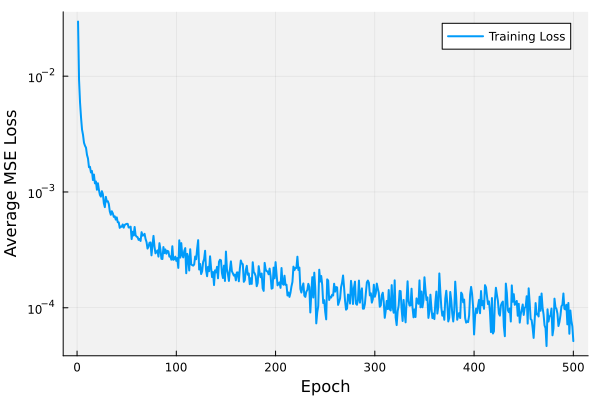

In [7]:
let
    # plot loss history on log scale to visualize convergence -
    plot(1:length(loss_history), loss_history, xlabel="Epoch", ylabel="Average MSE Loss",
        label="Training Loss", lw=2, yscale=:log10, background_color_inside=:gray95)
end

### Things to think about
* __Why can training loss be low but test predictions poor?__ The training loss is computed using teacher forcing, where the model receives the true state at every step. The evaluation in Task 4 uses autoregressive rollout, where the model receives its own predictions. Looking at the loss plot and the Task 4 results together, why can the training loss be very low (e.g., 5e-5) while some test conditions show poor predictions (MSE > 0.1)?

___

## Task 4: Evaluate Predictions
We evaluate the trained LSTM on the held-out test conditions using autoregressive rollout. Starting from the true initial state vector $\mathbf{s}_0$, the model feeds its own predictions back as input at each subsequent time step.

> __Autoregressive rollout for multi-state systems__
>
> During evaluation, the model must use its own predictions for all 7 states, which means errors in any state can compound and affect predictions of other states through the shared hidden representation. 
> 
> [The `predict_sequence(...)` function](src/LSTM.jl) implements this rollout, and [the `denormalize_minmax(...)` function](src/Simulation.jl) converts predictions back to their original scales.

Let's generate predictions for the test conditions and compare them to the ground truth. We plot four key states — biomass (X), glucose (Glc), antibody titer (mAb), and lactate (Lac) — for up to 4 representative test conditions, arranged as a grid with conditions as rows and species as columns.

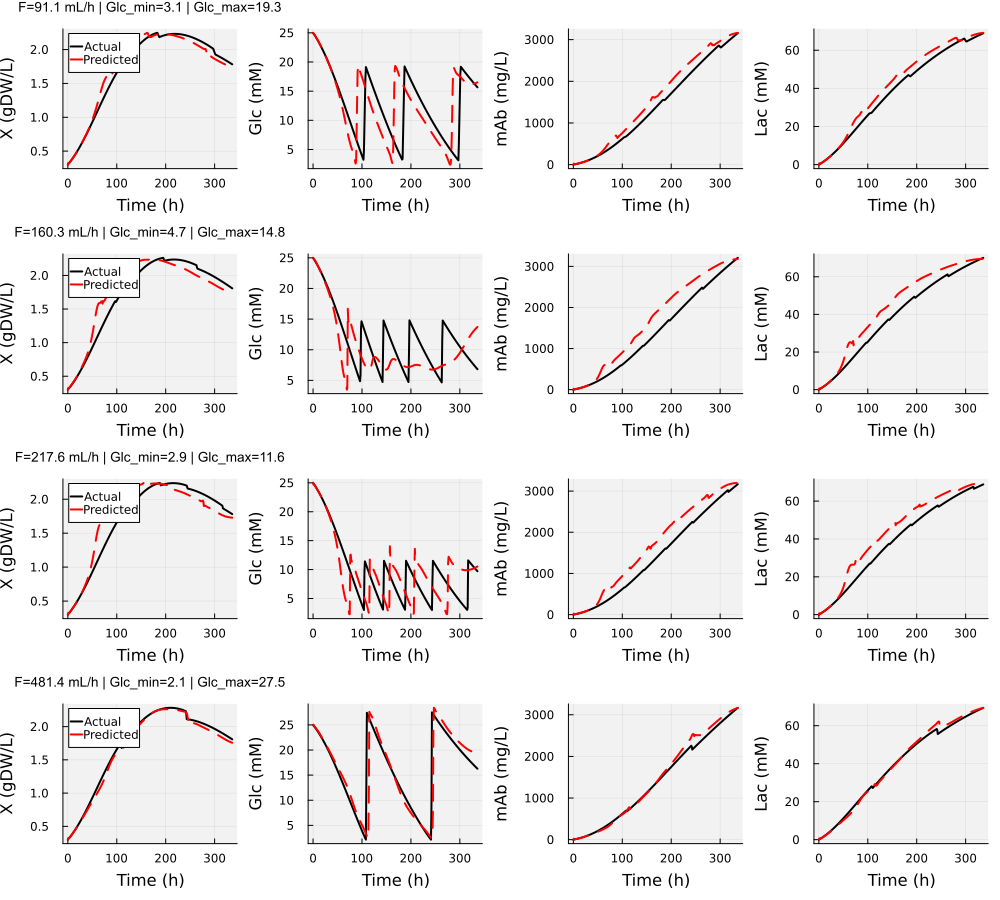

In [8]:
let

    # setup: determine how many test conditions to plot -
    n_test = length(test_idx);
    T = size(X_norm_arrays[1], 1);
    n_plots = min(n_test, 4);
    sorted_test = sort(test_idx, by=i -> conditions[i][1]); # sort by F_max
    plot_indices = sorted_test[round.(Int, range(1, n_test, length=n_plots))];

    # states to show: (state index, y-axis label) -
    plot_states = [(2, "X (gDW/L)"), (3, "Glc (mM)"), (5, "mAb (mg/L)"), (6, "Lac (mM)")];
    n_states = length(plot_states);

    # generate predictions and create subplots -
    plots_array = [];
    for idx in plot_indices

        # autoregressive prediction: start from true initial state and roll forward -
        x_0_vec = X_norm_arrays[idx][1, :];
        cond_vec = cond_norm[idx];
        pred_norm = predict_sequence(model, x_0_vec, cond_vec, T);

        # convert predictions back to original scale -
        pred_real = denormalize_minmax(pred_norm, state_mins, state_maxs);
        actual_real = state_arrays[idx];

        # build row title with full feed policy -
        F_max_mLh = round(conditions[idx][1] * 1000, digits=1);
        Glc_min_mM = round(conditions[idx][2], digits=1);
        Glc_max_mM = round(conditions[idx][3], digits=1);
        row_title = "F=$(F_max_mLh) mL/h | Glc_min=$(Glc_min_mM) | Glc_max=$(Glc_max_mM)";

        # create one panel per state for this condition -
        for (col, (s_idx, s_label)) in enumerate(plot_states)
            show_legend = col == 1;
            p = plot(time_vector, actual_real[:, s_idx];
                label=(show_legend ? "Actual" : false), lw=2, color=:black,
                xlabel="Time (h)", ylabel=s_label,
                title=(col == 1 ? row_title : ""), titlefont=font(9, "Arial"),
                background_color_inside=:gray95,
                legend=(show_legend ? :topleft : false));
            plot!(p, time_vector, pred_real[:, s_idx];
                label=(show_legend ? "Predicted" : false), lw=2, color=:red, ls=:dash);
            push!(plots_array, p);
        end
    end

    # layout: n_plots rows (one per condition) x n_states columns (one per species) -
    display(plot(plots_array..., layout=(n_plots, n_states), size=(1000, 900)))
end

Let's quantify the prediction quality for each test condition. We compare the final antibody titer, maximum biomass, and per-condition MSE (on the normalized scale to match the training loss) using [the `maximum(...)` function](https://docs.julialang.org/en/v1/base/collections/#Base.maximum) and [the `mean(...)` function](https://docs.julialang.org/en/v1/stdlib/Statistics/#Statistics.mean).

In [9]:
let

    # initialize -
    T = size(X_norm_arrays[1], 1);
    rows = [];

    # iterate over test conditions sorted by F_max -
    for idx in sort(test_idx, by=i -> conditions[i][1])

        # generate autoregressive prediction -
        x_0_vec = X_norm_arrays[idx][1, :];
        cond_vec = cond_norm[idx];
        pred_norm = predict_sequence(model, x_0_vec, cond_vec, T);

        # convert to original scale -
        pred_real = denormalize_minmax(pred_norm, state_mins, state_maxs);
        actual_real = state_arrays[idx];

        # compute metrics -
        actual_titer = actual_real[end, 5];       # final antibody titer (mg/L)
        pred_titer = pred_real[end, 5];            # predicted final titer (mg/L)
        actual_max_X = maximum(actual_real[:, 2]); # max biomass (gDW/L)
        pred_max_X = maximum(pred_real[:, 2]);     # predicted max biomass (gDW/L)

        # MSE on normalized scale to match training loss -
        actual_norm = X_norm_arrays[idx];
        mse = mean((pred_norm .- actual_norm) .^ 2);

        # add row to table -
        push!(rows, (
            F_max_mLh = round(conditions[idx][1] * 1000, digits=1),
            Glc_min_mM = round(conditions[idx][2], digits=1),
            Glc_max_mM = round(conditions[idx][3], digits=1),
            Actual_Titer = round(actual_titer, digits=1),
            Pred_Titer = round(pred_titer, digits=1),
            Actual_maxX = round(actual_max_X, digits=2),
            Pred_maxX = round(pred_max_X, digits=2),
            MSE = round(mse, sigdigits=4)
        ));
    end

    # display as a formatted table -
    df = DataFrame(rows);
    pretty_table(df;
        backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__simple),
    )
end

============ ============ ============ ============== ============ ============= =========== ===========
  F_max_mLh   Glc_min_mM   Glc_max_mM   Actual_Titer   Pred_Titer   Actual_maxX   Pred_maxX        MSE 
    Float64      Float64      Float64        Float64      Float64       Float64     Float64    Float64 
============ ============ ============ ============== ============ ============= =========== ===========
       91.1          3.1         19.3         3154.4       3162.6          2.25        2.25    0.01467
      129.9          1.2         20.9         3198.4       3225.7          2.27        2.25    0.02043
      156.7          3.1         26.7         3195.0       3083.1          2.29        2.27   0.004639
      160.3          4.7         14.8         3208.4       3178.3          2.26        2.24    0.01108
      178.9          1.4         11.6         3155.9       3224.2          2.24        2.22    0.01013
      204.9          2.3         18.7         3146.7       3177.7  

### Things to think about
* __Which test conditions are hardest to predict?__ In the results table, identify the test condition with the highest MSE. What is it about that condition's feed policy (F_max, Glc_min, Glc_max) that makes it harder to predict than the low-MSE conditions?

___

## Summary
In this example, we built a kinetic model of a fed-batch CHO bioreactor, generated multi-state time series data under different glucose-triggered feed policies, trained an LSTM to predict all seven bioreactor states, and evaluated predictions using autoregressive rollout.

> __Key Takeaways:__
>
> * **Kinetic ODE models provide structured multi-state training data for LSTMs:** The fed-batch CHO model generates seven coupled state trajectories that vary systematically with feed policy, providing a controlled dataset for training and evaluating multi-output sequence prediction models.
> * **LSTM gating mechanisms handle complex temporal dynamics:** The cell state highway and gating architecture allow the LSTM to capture the coupled dynamics of cell growth, substrate consumption, product formation, and by-product accumulation over a 10-day fed-batch culture.
> * **Multi-state autoregressive rollout compounds errors across states:** During evaluation, prediction errors in any state propagate to all other states through the shared hidden representation, making multi-output prediction more challenging than single-output prediction.

For more on LSTM architecture and gating mechanisms, see the [L12c lecture on LSTM Networks](CHEME-5820-L12c-Lecture-LSTM-Spring-2026.ipynb).
___